# 20. Neural Networks and Deep Learning Basics

A **neural network** is a cascade of linear transformations interleaved with
nonlinear activation functions. Even a shallow (one hidden layer) network is a
**universal approximator** — it can represent any continuous function given enough
neurons and appropriate training.

**Topics covered**
1. The perceptron and the multi-layer perceptron (MLP) architecture
2. Forward pass, loss function, and backpropagation
3. Quick prototyping with `sklearn.neural_network.MLPRegressor`
4. Building and training a network with **PyTorch**
5. Training curves, regularisation, and early stopping
6. Comparison: PLS vs RF vs MLP for NIR spectra prediction
7. Brief introduction to convolutional and graph neural networks for materials


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import cross_val_predict, KFold
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.neural_network import MLPRegressor
from sklearn.cross_decomposition import PLSRegression
from sklearn.ensemble import RandomForestRegressor
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

sns.set_theme(style='ticks', palette='colorblind')
plt.rcParams.update({'figure.dpi': 110, 'font.size': 11})
rng = np.random.default_rng(2024)
torch.manual_seed(0)
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Using device: {device}')


Using device: cpu


## 20.1 The Perceptron and MLP Architecture

A single **neuron** is really just a small regression model wearing a
disguise: it multiplies each input by a weight, adds them all up plus a
bias term (exactly like MLR's $\beta_0 + \beta_1x_1 + \cdots$), and then
passes that sum through a simple nonlinear function $f$:

$$a = f\!\left(\sum_{j=1}^p w_j x_j + b\right)$$

The nonlinear step is what makes a network more than "just regression" —
without it, stacking layers of neurons would collapse back into one single
linear model, no matter how many layers you stacked (adding straight lines
together only ever gives you another straight line). The nonlinearity lets
the network bend and combine simple functions into arbitrarily complex
shapes.

Common activation functions:

| Name | Formula | Use |
|---|---|---|
| ReLU | $\max(0,x)$ | Hidden layers (default) |
| Sigmoid | $1/(1+e^{-x})$ | Binary output |
| Tanh | $(e^x-e^{-x})/(e^x+e^{-x})$ | Hidden layers (zero-centred) |
| Linear | $x$ | Regression output |

An **MLP** (multi-layer perceptron) stacks layers of these neurons, each
layer's output feeding into the next layer's input. The depth (number of
layers) and width (neurons per layer) control how flexible a shape the
network can learn — more of either lets it fit more complex relationships,
at the cost of needing more data to avoid simply memorising noise
(overfitting, the same concern as an overly deep decision tree in Notebook
19).


## 20.2 Dataset: NIR Polymer Spectra → Tg

We reuse the NIR spectral dataset from Chapter 15 (PLS). 100 polymer samples, 50 wavenumber channels, response = glass transition temperature Tg (°C).

In [2]:
# ── Reproduce NIR dataset ─────────────────────────────────────────────────────
n_samples = 100
n_waves   = 50
wavenums  = np.linspace(3000, 4000, n_waves)

def gaussian(x, c, w): return np.exp(-0.5*((x-c)/w)**2)
profiles = np.column_stack([
    gaussian(wavenums, 3100, 60),
    gaussian(wavenums, 3300, 80),
    gaussian(wavenums, 3500, 50),
    gaussian(wavenums, 3700, 70),
    gaussian(wavenums, 3900, 55),
])
C = rng.normal(0, 1, (n_samples, 5))
Tg = -40 + 15*C[:,0] - 8*C[:,1] + 12*C[:,2] + 5*C[:,3] - 3*C[:,4] + rng.normal(0, 2, n_samples)
X_nir = C @ profiles.T + rng.normal(0, 0.05, (n_samples, n_waves))

scaler_nir = StandardScaler()
X_sc = scaler_nir.fit_transform(X_nir)
kf = KFold(n_splits=10, shuffle=True, random_state=42)

print(f'X: {X_sc.shape},  Tg range: {Tg.min():.1f}–{Tg.max():.1f} °C')


X: (100, 50),  Tg range: -97.1–1.4 °C


## 20.3 Quick Start: sklearn MLPRegressor

In [3]:
# ── sklearn MLP ───────────────────────────────────────────────────────────────
mlp_sk = MLPRegressor(
    hidden_layer_sizes=(64, 32),
    activation='relu',
    solver='adam',
    max_iter=500,
    learning_rate_init=1e-3,
    alpha=1e-4,          # L2 regularisation
    random_state=0,
    early_stopping=True,
    validation_fraction=0.1,
)

y_mlp_sk = cross_val_predict(mlp_sk, X_sc, Tg, cv=kf)
q2_mlp   = r2_score(Tg, y_mlp_sk)
rmse_mlp = np.sqrt(mean_squared_error(Tg, y_mlp_sk))
print(f'sklearn MLP  Q² = {q2_mlp:.4f},  RMSECV = {rmse_mlp:.2f} °C')


sklearn MLP  Q² = 0.5482,  RMSECV = 14.20 °C


## 20.4 Building a Network with PyTorch

`MLPRegressor` above hides the training details behind one `.fit()` call.
Building the same network in PyTorch makes the training loop explicit,
which is worth seeing at least once conceptually:

1. **Forward pass** — feed a batch of spectra through the network to get
   predictions, exactly as the formula in Section 20.1 describes, layer
   after layer.
2. **Loss function** — compare the predictions to the true Tg values with a
   single number summarising "how wrong were we?" (mean squared error here
   — the same quantity minimised by ordinary least squares in Part III).
3. **Backpropagation** — work backwards through the network applying the
   chain rule to figure out how much *each individual weight* contributed
   to that error. This is the computational trick that makes training deep
   networks feasible: instead of guessing how to adjust thousands of
   weights, backprop computes the exact direction each one should move to
   reduce the loss.
4. **Optimiser step** — nudge every weight a small distance in the
   direction backprop identified (here, the Adam optimiser — a more
   adaptive version of the basic "take a step downhill" idea used by
   gradient-based optimisation throughout this course).

Repeating these four steps over many **epochs** (passes through the
training data) gradually reduces the loss — the training curve below
tracks this directly. The **validation loss** curve alongside it is what
justifies **early stopping**: once validation loss stops improving even as
training loss keeps falling, the network has moved from learning the
underlying trend to memorising noise in the training set, and further
training should be stopped.

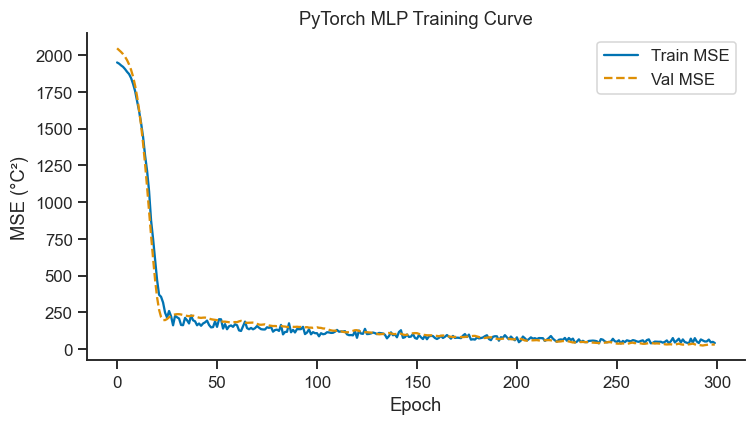

In [4]:
# ── Define network ────────────────────────────────────────────────────────────
class SpectralMLP(nn.Module):
    def __init__(self, n_input, hidden=(64, 32), dropout=0.2):
        super().__init__()
        layers = []
        prev = n_input
        for h in hidden:
            layers += [nn.Linear(prev, h), nn.ReLU(), nn.Dropout(dropout)]
            prev = h
        layers.append(nn.Linear(prev, 1))
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x).squeeze(-1)


# ── Train / validation split ──────────────────────────────────────────────────
n_train = 80
idx = rng.permutation(n_samples)
X_tr = torch.tensor(X_sc[idx[:n_train]],   dtype=torch.float32).to(device)
y_tr = torch.tensor(Tg[idx[:n_train]],      dtype=torch.float32).to(device)
X_va = torch.tensor(X_sc[idx[n_train:]],    dtype=torch.float32).to(device)
y_va = torch.tensor(Tg[idx[n_train:]],      dtype=torch.float32).to(device)

train_ds  = TensorDataset(X_tr, y_tr)
train_dl  = DataLoader(train_ds, batch_size=16, shuffle=True)

model = SpectralMLP(n_waves, hidden=(64, 32), dropout=0.2).to(device)
optimizer = optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)
criterion = nn.MSELoss()

train_losses, val_losses = [], []
best_val, best_state = np.inf, None
patience, patience_ctr = 30, 0

for epoch in range(300):
    model.train()
    batch_losses = []
    for xb, yb in train_dl:
        optimizer.zero_grad()
        loss = criterion(model(xb), yb)
        loss.backward()
        optimizer.step()
        batch_losses.append(loss.item())
    train_losses.append(np.mean(batch_losses))

    model.eval()
    with torch.no_grad():
        val_loss = criterion(model(X_va), y_va).item()
    val_losses.append(val_loss)

    # Early stopping
    if val_loss < best_val - 1e-4:
        best_val = val_loss
        best_state = {k: v.clone() for k, v in model.state_dict().items()}
        patience_ctr = 0
    else:
        patience_ctr += 1
        if patience_ctr >= patience:
            print(f'Early stopping at epoch {epoch+1}')
            break

model.load_state_dict(best_state)

# ── Training curve ────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(train_losses, lw=1.5, label='Train MSE')
ax.plot(val_losses,   lw=1.5, label='Val MSE',   ls='--')
ax.set_xlabel('Epoch')
ax.set_ylabel('MSE (°C²)')
ax.set_title('PyTorch MLP Training Curve')
ax.legend()
sns.despine(ax=ax)
plt.tight_layout()
plt.show()


PyTorch MLP  R² (val) = 0.9468,  RMSE (val) = 4.80 °C


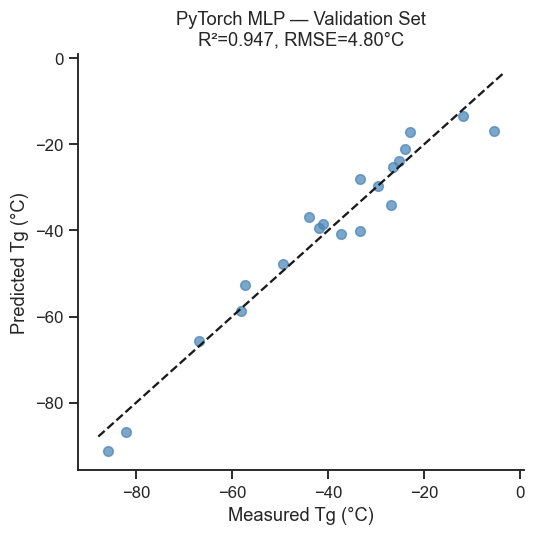

In [5]:
# ── Evaluate on validation set ────────────────────────────────────────────────
model.eval()
with torch.no_grad():
    Tg_va_pred = model(X_va).cpu().numpy()
Tg_va_true = Tg[idx[n_train:]]

r2_pt   = r2_score(Tg_va_true, Tg_va_pred)
rmse_pt = np.sqrt(mean_squared_error(Tg_va_true, Tg_va_pred))
print(f'PyTorch MLP  R² (val) = {r2_pt:.4f},  RMSE (val) = {rmse_pt:.2f} °C')

fig, ax = plt.subplots(figsize=(5, 5))
ax.scatter(Tg_va_true, Tg_va_pred, s=40, alpha=0.7, color='steelblue')
lims = [Tg_va_true.min()-2, Tg_va_true.max()+2]
ax.plot(lims, lims, 'k--', lw=1.5)
ax.set_xlabel('Measured Tg (°C)')
ax.set_ylabel('Predicted Tg (°C)')
ax.set_title(f'PyTorch MLP — Validation Set\n' + f'R²={r2_pt:.3f}, RMSE={rmse_pt:.2f}°C')
sns.despine(ax=ax)
plt.tight_layout()
plt.show()


## 20.5 Comparison: PLS vs RF vs MLP

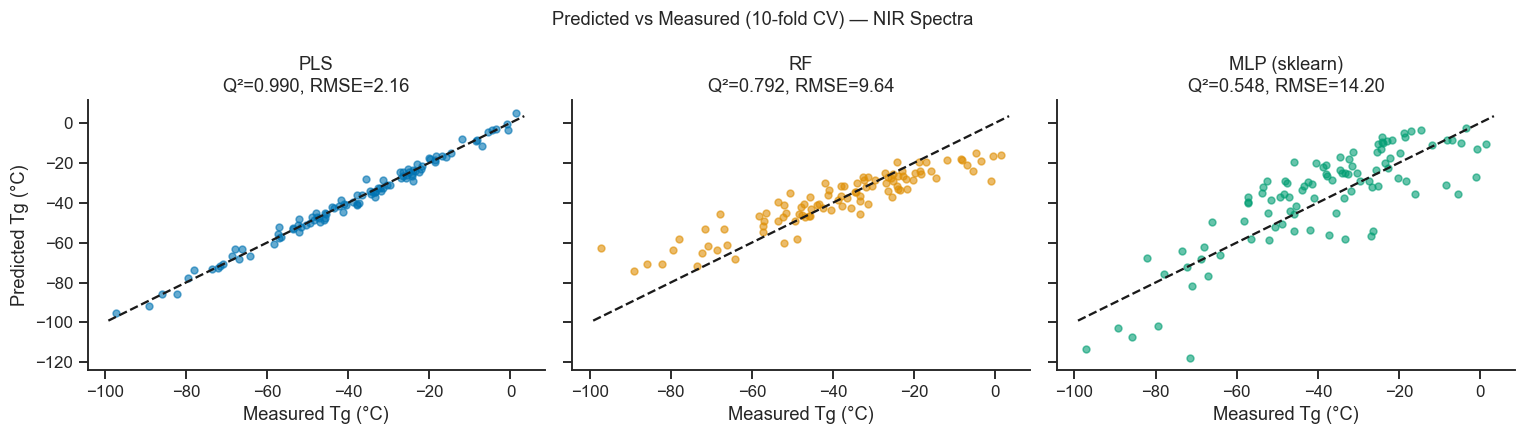


Model                Q²     RMSECV
------------------------------------
PLS              0.9895       2.16
RF               0.7916       9.64
MLP (sklearn)    0.5482      14.20


In [6]:
# ── Collect CV results for all methods ───────────────────────────────────────
pls_bench = PLSRegression(n_components=4, scale=False)
rf_bench  = RandomForestRegressor(n_estimators=200, max_features='sqrt',
                                   min_samples_leaf=2, random_state=0)

results = {}
for name, model_b in [('PLS', pls_bench), ('RF', rf_bench), ('MLP (sklearn)', mlp_sk)]:
    yp = cross_val_predict(model_b, X_sc, Tg, cv=kf)
    results[name] = {'Q2': r2_score(Tg, yp),
                     'RMSE': np.sqrt(mean_squared_error(Tg, yp)),
                     'y_cv': yp}

fig, axes = plt.subplots(1, 3, figsize=(14, 4), sharey=True, sharex=True)
for ax, (name, res), color in zip(axes, results.items(),
                                   sns.color_palette('colorblind', 3)):
    ax.scatter(Tg, res['y_cv'], s=20, alpha=0.6, color=color)
    lims = [Tg.min()-2, Tg.max()+2]
    ax.plot(lims, lims, 'k--', lw=1.5)
    ax.set_title(f'{name}\nQ²={res["Q2"]:.3f}, RMSE={res["RMSE"]:.2f}')
    ax.set_xlabel('Measured Tg (°C)')
    sns.despine(ax=ax)
axes[0].set_ylabel('Predicted Tg (°C)')
plt.suptitle('Predicted vs Measured (10-fold CV) — NIR Spectra', fontsize=12)
plt.tight_layout()
plt.show()

print(f"\n{'Model':<14} {'Q²':>8} {'RMSECV':>10}")
print('-' * 36)
for name, res in results.items():
    print(f"{name:<14} {res['Q2']:>8.4f} {res['RMSE']:>10.2f}")


### Interpreting the Comparison

In this NIR spectroscopy case:
- **PLS** performs excellently because the data has a strong linear latent structure — the five spectral profiles were designed to be linearly mixed. PLS finds this efficiently in just 4 components.
- **RF** also performs well but requires more data to match PLS on intrinsically linear problems.
- **MLP** can match or exceed PLS when the dataset is large enough and the relationship is genuinely nonlinear, but requires more careful hyperparameter tuning and training.

**When to choose each method:**

| Scenario | Recommended |
|---|---|
| Spectroscopy, chemometrics (< 200 samples) | PLS |
| Mixed linear/nonlinear, 100–10 000 samples | RF or GBM |
| Large dataset (> 10 000), images, graphs | Deep learning (CNN, GNN) |
| Uncertain — compare all | Cross-validated benchmark |


## 20.6 Beyond MLP: CNNs and Graph Neural Networks (Concepts)

### Convolutional Neural Networks (CNNs) for Spectra

Instead of a fully connected MLP, a **1-D CNN** slides a learnable filter along the
spectrum. This is particularly powerful for spectral data because:
- Local filters learn characteristic absorption peaks regardless of position
- Weight sharing dramatically reduces the number of parameters
- Translational equivariance is built-in

```python
# Sketch of a 1-D CNN for spectral data (PyTorch)
class SpectralCNN(nn.Module):
    def __init__(self, n_channels, n_output=1):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv1d(1, 16, kernel_size=7, padding=3), nn.ReLU(),
            nn.Conv1d(16, 32, kernel_size=5, padding=2), nn.ReLU(),
            nn.AdaptiveAvgPool1d(16),
        )
        self.fc = nn.Sequential(nn.Linear(32*16, 64), nn.ReLU(), nn.Linear(64, n_output))
    def forward(self, x):
        return self.fc(self.conv(x.unsqueeze(1)).flatten(1)).squeeze(-1)
```

### Graph Neural Networks (GNNs) for Molecules/Crystals

Atomic structures are naturally represented as graphs: atoms = nodes,
bonds = edges.  **Message-passing** GNNs (e.g. CGCNN, MEGNet) aggregate
information from neighbouring atoms to predict bulk properties.
They are the state-of-the-art for property prediction from crystal structure
in computational materials science.


---
## Exercises

1. **Architecture search**: Try MLP architectures with 1, 2, and 3 hidden layers, varying the number of neurons. Plot Q² vs total parameter count. What is the smallest model that achieves Q² > 0.95?

2. **Dropout regularisation**: Increase the dropout rate from 0.2 to 0.5 in the PyTorch model. How does this affect the training curve and the validation R²?

3. **Transfer learning concept**: Suppose you have 500 NIR spectra from a different polymer system (different Tg range). Describe how you could (a) use the pre-trained weights from this notebook as initialisation (fine-tuning) and (b) freeze the first two hidden layers and only train the last layer. What are the expected benefits?
